<a href="https://colab.research.google.com/github/martim-p05/detecao-anatomia-abelhas/blob/bee_species_identification/03_evaluation_20_species.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.

Loading test data...
Loaded 1026 test images for the final exam.

Reconstructing species names...
Loading the trained model... This might take a minute.
Model loaded successfully.

Generating predictions... The AI is taking the exam!
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 575ms/step

CLASSIFICATION REPORT (Detailed Grades per Species)
                         precision    recall  f1-score   support

      Amegilla albigena       0.22      0.41      0.29        51
Amegilla quadrifasciata       0.17      0.80      0.28        51
       Andrena flavipes       0.00      0.00      0.00        51
    Andrena fulvicornis       0.22      0.16      0.18        51
  Anthophora bimaculata       0.16      0.41      0.23        54
    Anthophora plumipes       0.50      0.02      0.04        51
        Apis m adansoni       0.26      0.47      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


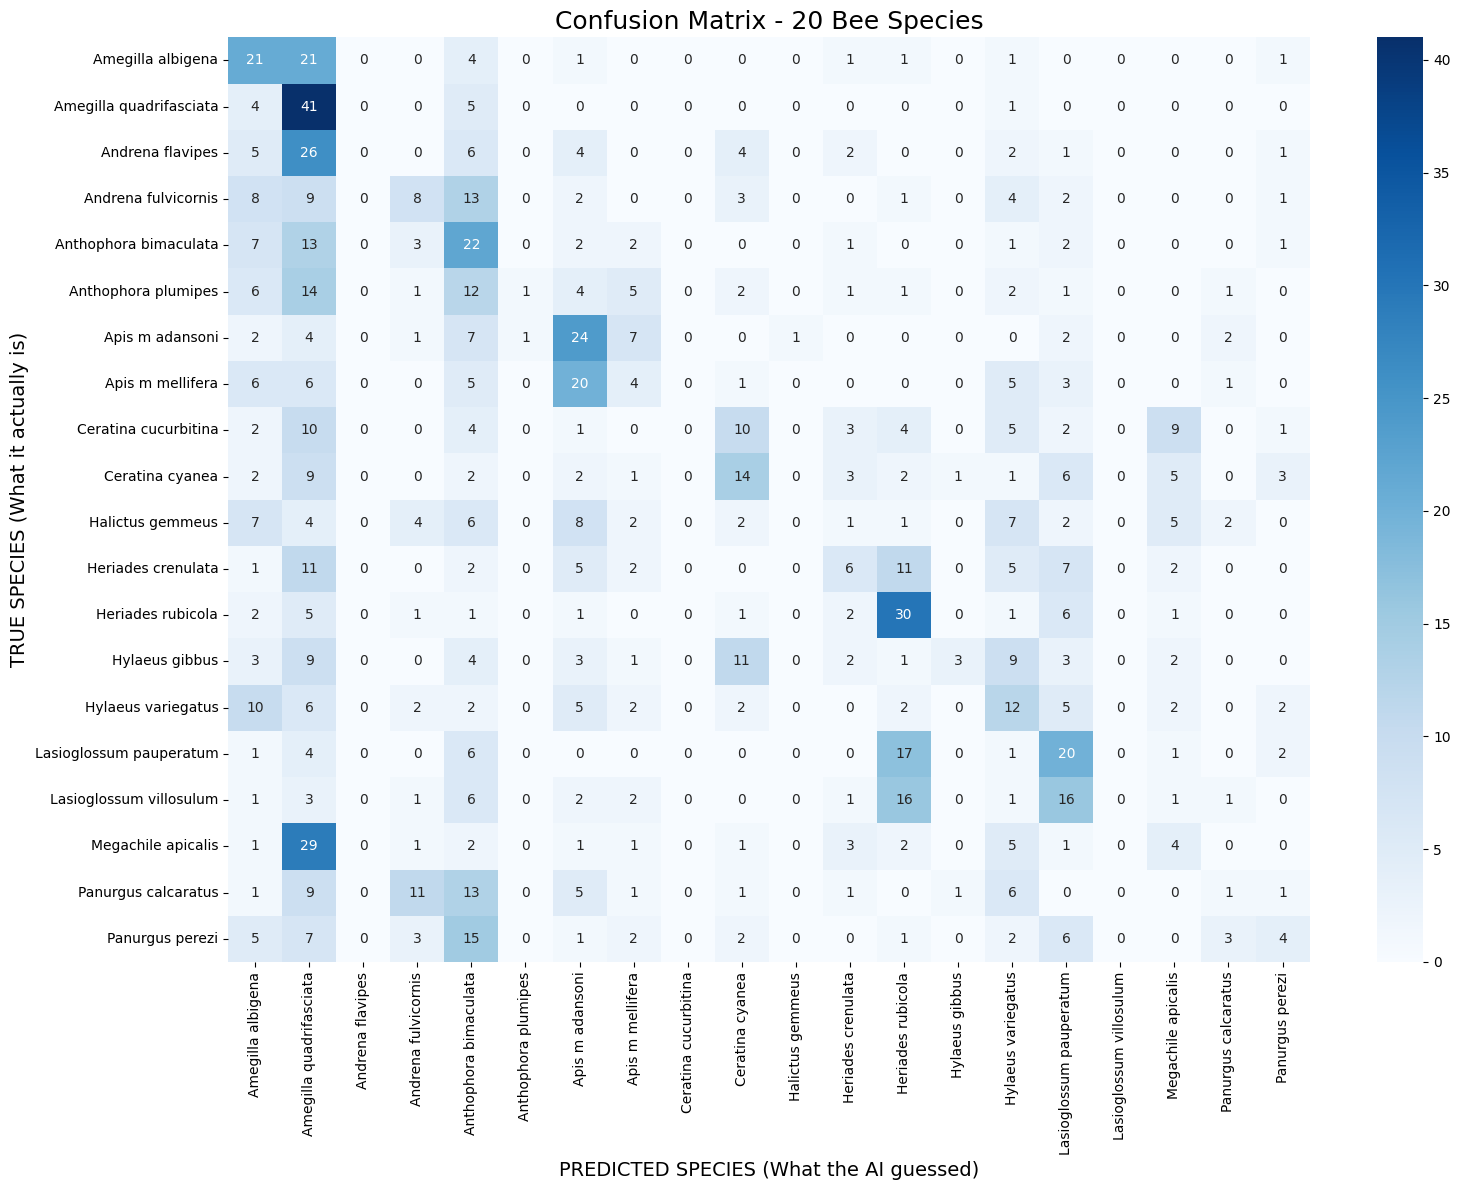

In [ ]:

from google.colab import drive
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 1 Mount Drive
drive.mount('/content/drive')
print("Google Drive mounted successfully.\n")

# 2 Define Paths
working_folder = Path('/content/drive/MyDrive/robin_2/')
test_data_path = working_folder / 'temp_files' / 'test_data_20_species.npz'
full_data_path = working_folder / 'temp_files' / 'dataset_20_species.npz'
model_path = working_folder / 'model' / 'bee_20_species_model.keras'

# 3 Load Test Data (The 10% hidden images)
print("Loading test data...")
test_data = np.load(test_data_path)
X_test = test_data['X_test']
y_test = test_data['y_test']
print(f"Loaded {X_test.shape[0]} test images for the final exam.\n")

# 4 Reconstruct Class Names (To know which species is which)
print("Reconstructing species names...")
full_data = np.load(full_data_path)
original_labels = full_data['labels']
encoder = LabelEncoder()
encoder.fit(original_labels)
class_names = encoder.classes_

# Free up memory immediately
del full_data
del original_labels

# 5 Load the Trained Model
print(f"Loading the trained model... This might take a minute.")
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully.\n")

# 6 Make Predictions
print("Generating predictions... The AI is taking the exam!")
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)

# 7 Generate Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Detailed Grades per Species)")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

# 8 Plot Confusion Matrix
print("\nGenerating Confusion Matrix Plot...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - 20 Bee Species', fontsize=18)
plt.ylabel('TRUE SPECIES (What it actually is)', fontsize=14)
plt.xlabel('PREDICTED SPECIES (What the AI guessed)', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()